<a href="https://colab.research.google.com/github/EberHernandezBenitez/EDP/blob/main/redes_ejemplos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datos del Sistema:

Nodos Oferta (Plantas): $P_1, P_2, P_3$ con capacidades de producción de 150, 200 y 150 unidades respectivamente.

Nodos Transbordo (CEDIS): $H_1, H_2, H_3, H_4, H_5$ (No consumen ni producen, su balance neto debe ser 0).

Nodos Demanda (Clientes): $C_1$ a $C_{12}$, cada uno con una demanda específica de entre 30 y 50 unidades (la demanda total suma 500 unidades, igual que la oferta total).

Reglas de Conectividad (Arcos):Las plantas no conectan directamente con los clientes; a fuerza deben pasar por los CEDIS.

Cada arco entre Planta $\rightarrow$ CEDIS y CEDIS $\rightarrow$ Cliente tiene un costo asociado por unidad y una capacidad máxima de envío para simular restricciones de transporte (por ejemplo, tamaño del camión).

Costo Mínimo Optimizado: $4,239


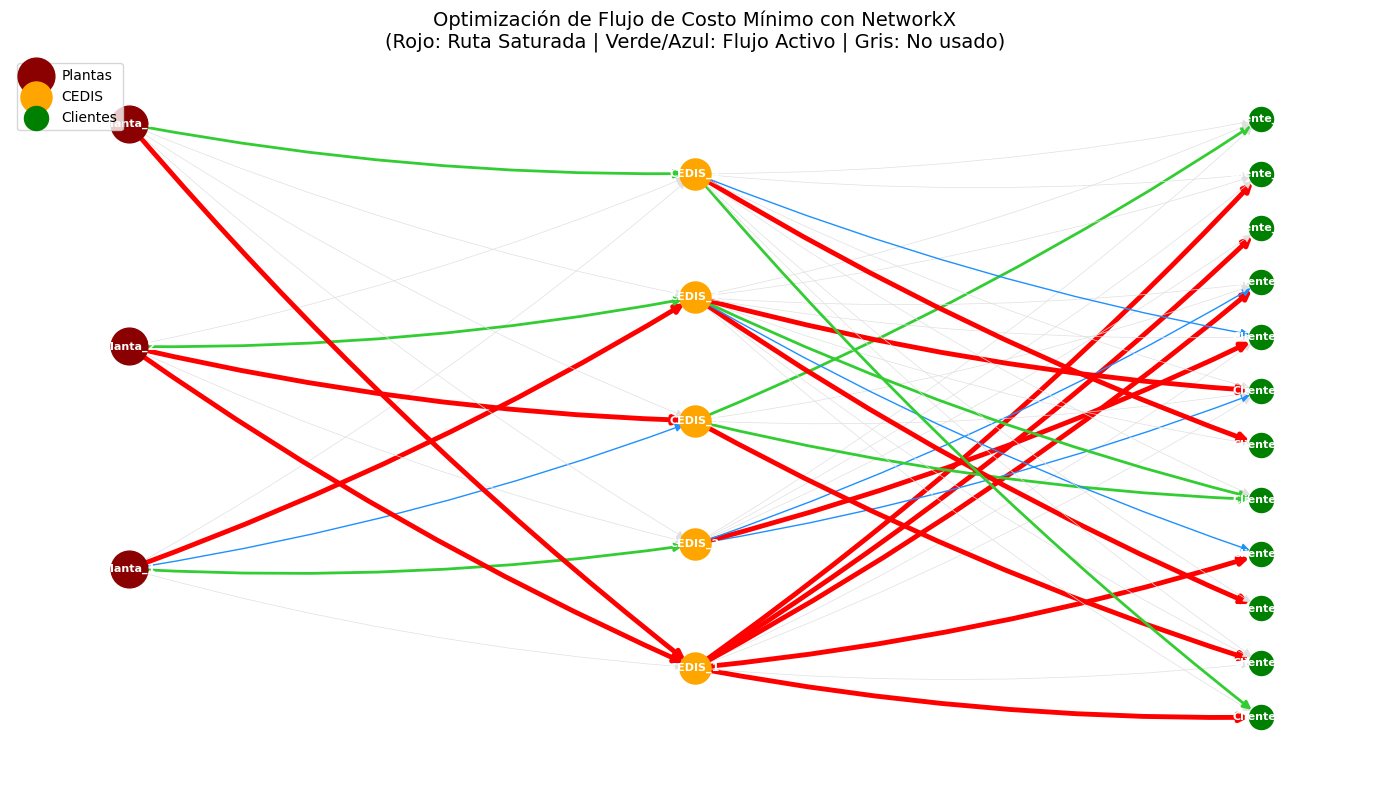

In [5]:
import networkx as nx
import random
import matplotlib.pyplot as plt

random.seed(42)
G = nx.DiGraph()

# ---- 1. DEFINICIÓN DE NODOS ----
plantas = {'Planta_1': -150, 'Planta_2': -200, 'Planta_3': -150}
clientes = {f'Cliente_{i}': 40 if i % 2 == 0 else 45 for i in range(1, 13)}
clientes['Cliente_12'] = 30  # Adjusted to balance total supply (500) and demand (500)
cedis = [f'CEDIS_{i}' for i in range(1, 6)]

for nodo, deficit in plantas.items(): G.add_node(nodo, demand=deficit)
for nodo in cedis: G.add_node(nodo, demand=0)
for nodo, dem in clientes.items(): G.add_node(nodo, demand=dem)

# ---- 2. CREACIÓN DE ARCOS REALISTAS ----
# Plantas -> CEDIS
for p in plantas:
    for h in cedis:
        # Forzamos un cuello de botella inicial bajando la capacidad de un arco clave
        cap = 15 if (p == 'Planta_1' and h == 'CEDIS_1') else random.randint(60, 100)
        G.add_edge(p, h, capacity=cap, weight=random.randint(2, 7))

# CEDIS -> Clientes
for h in cedis:
    for c in clientes:
        if random.random() > 0.3:
            G.add_edge(h, c, capacity=random.randint(25, 50), weight=random.randint(4, 12))

# ---- 3. RESOLVER EL MODELO ----
try:
    flow_cost = nx.min_cost_flow_cost(G)
    flow_dict = nx.min_cost_flow(G)
    print(f"Costo Mínimo Optimizado: ${flow_cost:,}")

    # ---- 4. PREPARAR LA VISUALIZACIÓN ----
    plt.figure(figsize=(14, 8))

    # Posicionar los nodos por capas (Layout personalizado para redes logísticas)
    pos = {}
    # Columna 1: Plantas
    for i, p in enumerate(plantas): pos[p] = (0, i * 4.5 + 3)
    # Columna 2: CEDIS
    for i, h in enumerate(cedis): pos[h] = (3, i * 2.5 + 1)
    # Columna 3: Clientes
    for i, c in enumerate(clientes): pos[c] = (6, i * 1.1)

    # Dibujar Nodos por categorías
    nx.draw_networkx_nodes(G, pos, nodelist=plantas.keys(), node_color='darkred', node_size=700, label='Plantas')
    nx.draw_networkx_nodes(G, pos, nodelist=cedis, node_color='orange', node_size=500, label='CEDIS')
    nx.draw_networkx_nodes(G, pos, nodelist=clientes.keys(), node_color='green', node_size=300, label='Clientes')

    # Dibujar Etiquetas de Nodos
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold')

    # Determinar colores y grosores de arcos según su nivel de uso (Saturación)
    edge_colors = []
    edge_widths = []

    for u, v in G.edges():
        flujo_real = flow_dict[u][v]
        capacidad_max = G[u][v]['capacity']
        saturacion = flujo_real / capacidad_max if capacidad_max > 0 else 0

        # Guardar en el grafo para referencia
        G[u][v]['flow'] = flujo_real

        # Definir color según saturación
        if flujo_real == 0:
            edge_colors.append('#E0E0E0') # Gris claro si no se usa
            edge_widths.append(0.5)
        elif saturacion > 0.8:
            edge_colors.append('#FF0000') # Rojo si está casi lleno (Cuello de botella)
            edge_widths.append(3.5)
        elif saturacion > 0.4:
            edge_colors.append('#32CD32') # Verde si está a flujo medio
            edge_widths.append(2.0)
        else:
            edge_colors.append('#1E90FF') # Azul si se usa poco
            edge_widths.append(1.0)

    # Dibujar los arcos
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                           arrowsize=12, connectionstyle="arc3,rad=0.05")

    plt.title("Optimización de Flujo de Costo Mínimo con NetworkX\n(Rojo: Ruta Saturada | Verde/Azul: Flujo Activo | Gris: No usado)", fontsize=14)
    plt.legend(loc='upper left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

except nx.NetworkXUnfeasible:
    print("¡Error! Las restricciones o capacidades impiden abastecer toda la demanda.")

Tenemos una red de calles con las siguientes capacidades (personas por minuto):

Origen: Estación de Metro.

Destino: Estadio.

Nodos Intermedios: Plazas o cruces (A, B, C).

Capacidades de las calles:

Del Metro al Cruce A: 50

Del Metro al Cruce B: 40

Del Cruce A al Cruce B: 10

Del Cruce A al Cruce C: 30

Del Cruce B al Cruce C: 20

Del Cruce B directo al Estadio: 30

Del Cruce C directo al Estadio: 50

Si sumas las salidas del Metro, pareciera que puedes enviar 90 personas por minuto. Pero, ¿realmente el sistema aguanta esa cantidad hasta el final?

Para resolver esto, NetworkX utiliza la función *nx.maximum_flow()*, la cual implementa algoritmos clásicos como el de Ford-Fulkerson o Edmonds-Karp. Estos algoritmos envían flujo por las rutas disponibles hasta que saturan los cuellos de botella y ya no hay caminos con capacidad libre hacia el destino.

--- RESULTADO DEL PLAN DE FLUJO ---
El flujo máximo que soporta la red es: 80 personas por minuto.

Distribución óptima por calle (Flujo enviado / Capacidad Total):
  De Metro a Cruce_A: 40 / 50
  De Metro a Cruce_B: 40 / 40
  De Cruce_A a Cruce_B: 10 / 10
  De Cruce_A a Cruce_C: 30 / 30
  De Cruce_B a Cruce_C: 20 / 20
  De Cruce_B a Estadio: 30 / 30
  De Cruce_C a Estadio: 50 / 50


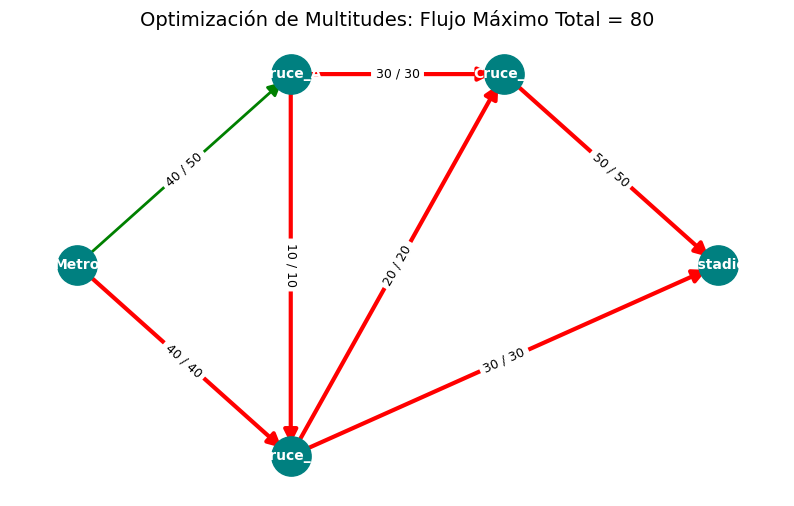

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Crear el Grafo Dirigido
G = nx.DiGraph()

# 2. Definir las rutas y su CAPACIDAD MÁXIMA (personas por minuto)
rutas = [
    ('Metro', 'Cruce_A', 50),
    ('Metro', 'Cruce_B', 40),
    ('Cruce_A', 'Cruce_B', 10),
    ('Cruce_A', 'Cruce_C', 30),
    ('Cruce_B', 'Cruce_C', 20),
    ('Cruce_B', 'Estadio', 30),
    ('Cruce_C', 'Estadio', 50)
]

# Añadir los arcos al grafo
for origen, destino, cap in rutas:
    G.add_edge(origen, destino, capacity=cap)

# 3. Calcular el Flujo Máximo
# La función devuelve dos cosas: el valor total máximo y el diccionario de cómo se distribuye
flujo_total, distribucion_flujo = nx.maximum_flow(G, _s='Metro', _t='Estadio') # Corrected: used _s and _t for source and target

print("--- RESULTADO DEL PLAN DE FLUJO ---")
print(f"El flujo máximo que soporta la red es: {flujo_total} personas por minuto.\n")

print("Distribución óptima por calle (Flujo enviado / Capacidad Total):")
for u, conexiones in distribucion_flujo.items():
    for v, flujo_real in conexiones.items():
        if flujo_real > 0:
            capacidad_max = G[u][v]['capacity']
            print(f"  De {u} a {v}: {flujo_real} / {capacidad_max}")

# 4. Graficar la red y mostrar los flujos
plt.figure(figsize=(10, 6))

pos = {
    'Metro': (0, 1),
    'Cruce_A': (1, 2),
    'Cruce_B': (1, 0),
    'Cruce_C': (2, 2),
    'Estadio': (3, 1)
}

nx.draw_networkx_nodes(G, pos, node_color='teal', node_size=800)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')

# Crear etiquetas para visualizar "Flujo / Capacidad" en los arcos
etiquetas_arcos = {}
edge_colors = []
edge_widths = []

for u, v in G.edges():
    f_real = distribucion_flujo[u][v]
    c_max = G[u][v]['capacity']
    etiquetas_arcos[(u, v)] = f"{f_real} / {c_max}"

    # Si la calle está saturada (flujo == capacidad), pintarla de rojo
    if f_real == c_max:
        edge_colors.append('red')
        edge_widths.append(3.0)
    elif f_real > 0:
        edge_colors.append('green')
        edge_widths.append(2.0)
    else:
        edge_colors.append('gray')
        edge_widths.append(1.0)

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas_arcos, font_size=9)

plt.title(f"Optimización de Multitudes: Flujo Máximo Total = {flujo_total}", fontsize=14)
plt.axis('off')
plt.show()